# Room-Temperature Body-Diode ANN


In [1]:
# Import the room-temperature data loader and the paper-style body-diode ANN.
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from DeviceData import load_body_diode_characteristics
from body_diode_hybrid import BodyDiodeNN, train_ibd_network, predict_ibd, save_ibd_pkl, load_ibd_pkl


## Load the room-temperature body-diode dataset


In [2]:
# Read Vds and Ibd from every Vgs curve in the 25 C body-diode folder.
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = load_body_diode_characteristics(TEMPLATE_DIR)
print(df.groupby(["T_C", "Vgs"]).size())
print("Total body-diode points =", len(df))

Vgs = torch.tensor(df["Vgs"].to_numpy(np.float32)).reshape(-1, 1)
Vds = torch.tensor(df["Vds"].to_numpy(np.float32)).reshape(-1, 1)
Ibd = torch.tensor(df["Ibd"].to_numpy(np.float32)).reshape(-1, 1)
MODEL_FILE = BASE_DIR / "Ibd_NN.pkl"

assert np.allclose(df["T_C"].to_numpy(), 25.0)


T_C   Vgs 
25.0  -5.0    30
      -2.0    29
       0.0    36
dtype: int64
Total body-diode points = 95


## Train Eq. (29) at room temperature


In [3]:
# Train the paper 2-6-6-1 body-diode network using only Vgs and Vds as inputs.
EPOCHS = 5000
LEARNING_RATE = 1.0e-4
BATCH_SIZE = 128
VAL_FRACTION = 0.20
SEED = 42

model, norm, history = train_ibd_network(
    Vgs,
    Vds,
    Ibd,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    seed=SEED,
    print_every=250,
    sign_weight=1.0,
    zero_weight=2.0,
    zero_width=0.50,
)
print("Best validation loss =", history.best_val_loss)


TypeError: train_ibd_network() got an unexpected keyword argument 'sign_weight'

In [ ]:
# Save the trained room-temperature body-diode neural network as a structured .pkl file.
save_ibd_pkl(
    MODEL_FILE,
    model,
    norm,
    training_metadata={
        "temperature_C": 25.0,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "validation_fraction": VAL_FRACTION,
        "seed": SEED,
        "best_validation_loss": float(history.best_val_loss),
        "number_of_samples": int(len(df)),
    },
)
print("Saved =", MODEL_FILE)


Saved = c:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\Ibd_NN.pkl


## Static-characteristic accuracy


In [ ]:
# Predict every room-temperature datasheet point and report the static-current fit error.
Ibd_pred = predict_ibd(
    model,
    norm,
    Vgs.reshape(-1),
    Vds.reshape(-1),
    device=device,
).cpu().numpy().reshape(-1)
Ibd_true = Ibd.numpy().reshape(-1)
error = Ibd_pred - Ibd_true
print("RMSE =", float(np.sqrt(np.mean(error**2))), "A")
print("MAE =", float(np.mean(np.abs(error))), "A")


RMSE = 3.897956371307373 A
MAE = 2.597768783569336 A


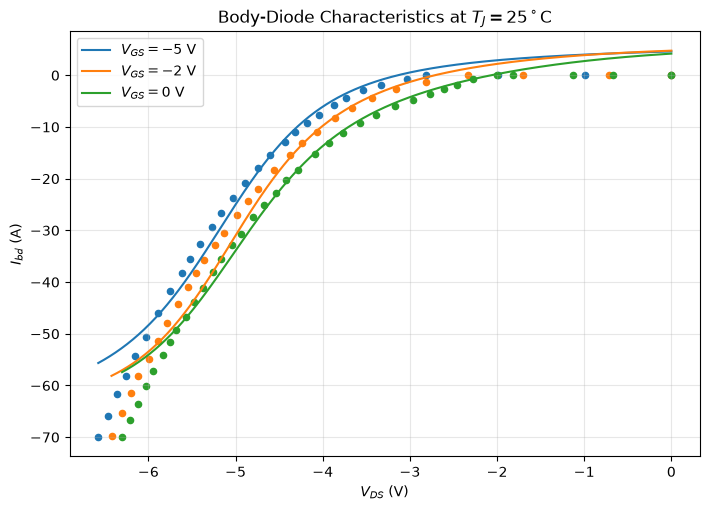

In [ ]:
# Plot the measured and ANN body-diode curves at 25 C.
plt.figure(figsize=(7.2, 5.2))
for vgs_value in sorted(df["Vgs"].unique()):
    measured = df[np.isclose(df["Vgs"], vgs_value)].sort_values("Vds")
    plt.scatter(measured["Vds"], measured["Ibd"], s=20)
    Vds_curve = np.linspace(measured["Vds"].min(), 0.0, 300)
    Vgs_curve = np.full_like(Vds_curve, vgs_value)
    Ibd_curve = predict_ibd(model, norm, Vgs_curve, Vds_curve, device=device).cpu().numpy().reshape(-1)
    plt.plot(Vds_curve, Ibd_curve, label=rf"$V_{{GS}}={vgs_value:g}$ V")
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{bd}$ (A)")
plt.title(r"Body-Diode Characteristics at $T_J=25^\circ$C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Verify that the saved room-temperature .pkl file reloads independently.
model_loaded, norm_loaded, checkpoint = load_ibd_pkl(MODEL_FILE, device=device)
print(checkpoint["model_name"])
print(checkpoint["architecture"])
print(checkpoint["input_names"])


SiC_MOSFET_Body_Diode_ANN
{'input_dim': 2, 'hidden_dims': [6, 6], 'output_dim': 1, 'activation': 'tanh'}
['Vgs', 'Vds']


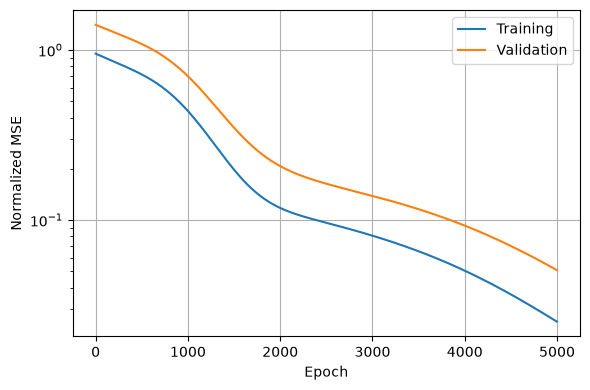

In [ ]:
# Plot the training and validation losses.
plt.figure(figsize=(6, 4))
plt.semilogy(history.train_loss, label="Training")
plt.semilogy(history.val_loss, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Normalized MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
